<a href="https://colab.research.google.com/github/jiayeekwong/telcoshield/blob/main/GeoAI_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 — Start logging river level

In [4]:
import io, requests, pandas as pd
pd.set_option("display.width", 200)

DATA = ("https://publicinfobanjir.water.gov.my/aras-air/data-paras-air/"
        "aras-air-data/?state=KEL&district=ALL&station=ALL&lang=en")

tables = pd.read_html(io.StringIO(requests.get(DATA, timeout=60).text))
print(f"{len(tables)} table(s)")
df = tables[0]
print(df.columns.tolist())
print(df.head(3).to_string())

1 table(s)
[('No.', 'No.'), ('Station ID', 'Station ID'), ('Station Name', 'Station Name'), ('District', 'District'), ('Main Basin', 'Main Basin'), ('Sub River Basin', 'Sub River Basin'), ('Last Updated', 'Last Updated'), ('Water Level (m) (Graph)', 'Water Level (m) (Graph)'), ('Threshold', 'Normal'), ('Threshold', 'Alert'), ('Threshold', 'Warning'), ('Threshold', 'Danger')]
  No. Station ID                   Station Name    District       Main Basin Sub River Basin      Last Updated Water Level (m) (Graph) Threshold                      
  No. Station ID                   Station Name    District       Main Basin Sub River Basin      Last Updated Water Level (m) (Graph)    Normal  Alert Warning Danger
0   1  0730891WL   Sg. Nenggiri di Belatop (F1)  Gua Musang  Sungai Kelantan    Sg. Nenggiri  08/08/2026 14:00                  612.10     605.5  676.0   678.0  680.0
1   2        NaN    Sg. Galas di Kg. Pulai (F1)  Gua Musang  Sungai Kelantan       Sg. Galas  08/08/2026 14:15           

In [14]:
"""
step1_scrape_river.py — log DID InfoBanjir river levels hourly.

WHY: InfoBanjir has no historical bulk endpoint. Capture forward or lose it.
"""
import io, sys, datetime as dt, requests, pandas as pd
from pathlib import Path

STATES = ["KEL"]                    # add "PHG", "TRG", "SEL"
LOG    = Path("data/river_log.csv")
URL    = ("https://publicinfobanjir.water.gov.my/aras-air/data-paras-air/"
          "aras-air-data/?state={s}&district=ALL&station=ALL&lang=en")

COLMAP = {
    "station id station id":                   "station_id",
    "station name station name":               "station",
    "district district":                       "district",
    "main basin main basin":                   "basin",
    "sub river basin sub river basin":         "river",
    "last updated last updated":               "updated",
    "water level (m) (graph) water level (m) (graph)": "level",
    "threshold normal":                        "normal",
    "threshold alert":                         "alert",
    "threshold warning":                       "warning",
    "threshold danger":                        "danger",
}


def fetch(state):
    r = requests.get(URL.format(s=state), timeout=60)
    r.raise_for_status()
    df = pd.read_html(io.StringIO(r.text))[0]
    df.columns = [" ".join(str(c) for c in col).strip().lower()
                  for col in df.columns]
    return df


def parse(df, state):
    missing = [k for k in COLMAP if k not in df.columns]
    if missing:
        raise KeyError(f"table layout changed, missing: {missing}")

    out = df[list(COLMAP)].rename(columns=COLMAP).copy()

    for c in ["level", "normal", "alert", "warning", "danger"]:
        out[c] = pd.to_numeric(
            out[c].astype(str).str.extract(r"(-?\d+\.?\d*)")[0], errors="coerce")

    out["updated"] = pd.to_datetime(out.updated, format="%d/%m/%Y %H:%M",
                                    errors="coerce").dt.tz_localize("Asia/Kuala_Lumpur")

    # Empangan/dam gauges sit near "danger" by design — reservoirs are meant to
    # be full. Left in, they generate permanent false escalations year-round.
    out["is_reservoir"] = out.station.str.contains(
        "empangan|dam|kolam|takungan", case=False, na=False)

    # normalised stress: 0 = at normal, 1 = at danger. Raw metres are not
    # comparable across gauges because every station has a different datum.
    span = out.danger - out.normal
    out["stress"] = ((out.level - out.normal) / span.where(span > 0)).clip(0, 1.5)

    # a 70 m normal->danger span is not a real river gauge
    out["suspect"] = (span > 20) | (span <= 0)

    out["state"] = state
    out["scraped_at"] = dt.datetime.now(dt.timezone.utc).isoformat()
    return out.dropna(subset=["station"])


def main():
    dry = "--dry" in sys.argv
    LOG.parent.mkdir(parents=True, exist_ok=True)

    frames = []
    for s in STATES:
        try:
            frames.append(parse(fetch(s), s))
        except Exception as e:
            print(f"{s}: FAILED — {e}")

    if not frames:
        print("nothing scraped; log untouched")
        return
    new = pd.concat(frames, ignore_index=True)

    if not dry:
        # schema guard: adding a column mid-run silently corrupts the log,
        # and you only find out when read_csv fails days later
        if LOG.exists():
            old = pd.read_csv(LOG, nrows=0).columns.tolist()
            if old != new.columns.tolist():
                stamp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
                LOG.rename(LOG.with_name(f"river_log_{stamp}.csv"))
                print(f"** schema changed — archived as river_log_{stamp}.csv **")
        new.to_csv(LOG, mode="a", header=not LOG.exists(), index=False)

    stale = (pd.Timestamp.now(tz="Asia/Kuala_Lumpur")
             - new.updated.max()).total_seconds() / 60
    print(f"{len(new)} rows | {new.level.notna().sum()} numeric | "
          f"{new.suspect.sum()} suspect | {new.is_reservoir.sum()} reservoir | "
          f"newest reading {stale:.0f} min old")
    print(new[~new.is_reservoir].nlargest(5, "stress")[
        ["station", "level", "normal", "danger", "stress"]].to_string(index=False))


if __name__ == "__main__":
    main()

32 rows | 32 numeric | 1 suspect | 1 reservoir | newest reading 32 min old
                       station  level  normal  danger   stress
  Sg. Pergau di Kg. Lawar (F1)  99.32    95.0   103.0 0.540000
Sg. Kelantan di Kg. Salor (F1)   5.38     1.0    10.6 0.456250
  Sg. Semerak di Tok Bali (F2)   1.36     0.0     4.0 0.340000
 Sg. Golok di Kuala Jambu (F1)   1.10     0.7     3.0 0.173913
Sg. Lebir di Kg. Karangan (F1)  21.45    19.0    34.0 0.163333


Step 2 — Get towers, and check density

In [21]:
import numpy as np, pandas as pd
from sklearn.cluster import DBSCAN
from scipy.spatial import cKDTree

COLS = ["radio","mcc","net","area","cell","unit","lon","lat",
        "range","samples","changeable","created","updated","avg_signal"]

df = pd.read_csv("502.csv", names=COLS, header=None, low_memory=False)
print(f"{len(df):,} cells nationwide")

# Kelantan bbox — must match `kel` in the GEE script
s, w, n, e = 4.30, 101.30, 6.30, 102.70
d = df[df.lat.between(s, n) & df.lon.between(w, e)].copy()
print(f"{len(d):,} cells in bbox")

# Quality filter. `range` is OpenCelliD's own position uncertainty and the
# median here is ~2 km. HAND changes completely over that distance, so an
# imprecise tower gets meaningless terrain features.
q = d[(d.samples >= 3) & (d["range"] <= 2000)].copy()
print(f"{len(q):,} after quality filter")

# Cluster into physical sites. Rounding coordinates does NOT work: OpenCelliD
# positions are averaged from crowdsourced measurements, so co-located sectors
# land on slightly different lat/lon and never match exactly.
xy = np.column_stack([q.lon * 111.32 * np.cos(np.radians(q.lat)), q.lat * 110.57])
q["site"] = DBSCAN(eps=0.30, min_samples=1).fit_predict(xy)

sites = (q.groupby("site")
           .agg(lat=("lat","mean"), lon=("lon","mean"),
                n_cells=("cell","size"), operators=("net","nunique"),
                samples=("samples","sum"))
           .reset_index(drop=True))
sites.insert(0, "tower_id", [f"T{i:05d}" for i in range(len(sites))])

# Neighbour geometry — project to km first, degrees will lie to you
X = np.column_stack([sites.lon * 111.32 * np.cos(np.radians(sites.lat)),
                     sites.lat * 110.57])
tree = cKDTree(X)
dd, _ = tree.query(X, k=4)
sites["nn_dist_km"]   = dd[:, 1:].mean(axis=1)
sites["n_within_5km"] = tree.query_ball_point(X, r=5.0, return_length=True) - 1

sites.to_parquet("data/towers.parquet", index=False)
sites.to_csv("kel_towers.csv", index=False)     # this is what GEE wants

print(f"\n{len(sites):,} sites | median spacing {sites.nn_dist_km.median():.2f} km "
      f"| isolated {(sites.n_within_5km==0).sum()}")

95,176 cells nationwide
3,891 cells in bbox
1,442 after quality filter

716 sites | median spacing 1.09 km | isolated 11


TRaining


In [23]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
tr = pd.read_csv('/content/drive/MyDrive/telcoshield/samples_2024.csv')
te = pd.read_csv('/content/drive/MyDrive/telcoshield/samples_2022.csv')
print(tr.shape, tr.columns.tolist())
print(tr.flood.value_counts())
print(tr[['elev','slope','hand','twi','upa']].describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(8000, 13) ['system:index', 'block', 'elev', 'flood', 'gsw_occ', 'hand', 'landcover', 'lat', 'lon', 'slope', 'twi', 'upa', '.geo']
flood
0    4000
1    4000
Name: count, dtype: int64
              elev        slope         hand          twi           upa
count  8000.000000  8000.000000  8000.000000  8000.000000   8000.000000
mean     35.738938     1.544028     2.275300     1.197023     10.381919
std      97.547805     1.488115     3.164320     2.601681    177.461621
min      -1.594608     0.000000     0.000000    -2.168774      0.008497
25%       2.564855     0.286403     0.200001    -0.776356      0.008502
50%       8.480866     0.893229     0.900000     0.692757      0.016999
75%      27.422878     2.702485     2.800002     2.302585      0.093561
max    1531.855200     4.999251    14.900024    15.009776  11220.374000


**Training**

In [24]:
!pip install xgboost shap -q

In [27]:
import os
os.makedirs('/content/drive/MyDrive/telcoshield/data', exist_ok=True)

In [29]:
tr_all = prep(pd.read_csv(f"{BASE}/samples_2024.csv")).dropna(subset=FEATS_NO_LC+["flood"])
north = tr_all[tr_all.lat >= 5.3]
south = tr_all[tr_all.lat <  5.3]
print(f"north {len(north)} (flood {north.flood.mean():.2f})  "
      f"south {len(south)} (flood {south.flood.mean():.2f})")

m = make_model().fit(south[FEATS_NO_LC], south.flood)
p = m.predict_proba(north[FEATS_NO_LC])[:,1]
print(f"south -> north PR-AUC {average_precision_score(north.flood, p):.3f} "
      f"(base {north.flood.mean():.3f})")

north 7190 (flood 0.55)  south 810 (flood 0.02)
south -> north PR-AUC 0.845 (base 0.554)


In [32]:
"""
train_susceptibility.py — TelcoShield Layer A

Trains flood susceptibility on Sentinel-1 labels, validates honestly, and
writes a per-tower `baseline` column for the live engine.

VALIDATION DESIGN
  - Spatial CV by 0.1-degree block. Random CV leaks badly: neighbouring
    pixels are near-identical, so a random split puts effectively the same
    sample in train and test and inflates every metric.
  - Out-of-event holdout: train on 2024, test on 2022. Same orbit, same
    look geometry, genuinely unseen flood. This is the number for the pitch.
  - Permutation test: shuffle labels, retrain, confirm PR-AUC collapses to
    base rate. Cheapest leak detector there is.
  - SHAP sign check: higher HAND must LOWER flood probability. If it does
    not, you have a feature bug, not a discovery.

Run in Colab:  pip install xgboost shap -q
"""
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.metrics import average_precision_score, roc_auc_score
import xgboost as xgb

import os
BASE = "/content/drive/MyDrive/telcoshield"
os.makedirs(f"{BASE}/data", exist_ok=True)

# lat/lon are DELIBERATELY excluded. With them the model memorises where the
# 2024 flood happened instead of learning what makes terrain floodable, and
# it will not transfer to 2022 or to a different state.
#
# Land cover is ALSO excluded. Included, lc_10 (tree cover) + lc_40 (cropland)
# reached 80% of feature importance and PR-AUC rose to 0.955 -- but that is the
# model learning the SENSOR, not hydrology. C-band SAR cannot see water under
# canopy, so forested pixels are labelled dry whether or not they flooded.
# Terrain-only costs ~0.02 PR-AUC and removes the artifact.
FEATS = ["elev", "slope", "hand", "log_upa", "twi", "gsw_occ"]


# ---------------------------------------------------------------- prep
def prep(df):
    df = df.drop(columns=[c for c in ["system:index", ".geo"] if c in df], errors="ignore")

    # upa is heavily zero-inflated: >25% of points sit at the MERIT single-pixel
    # floor (~0.0085 km2). Log-transform or the tail dominates every split.
    df["log_upa"] = np.log1p(df["upa"])

    # landcover is categorical (ESA WorldCover class codes), not ordinal.
    # One-hot only the classes that actually occur.
    if "landcover" in df:
        for c in sorted(df.landcover.dropna().unique()):
            df[f"lc_{int(c)}"] = (df.landcover == c).astype(int)

    df = df.replace([np.inf, -np.inf], np.nan)
    return df


def feature_cols(df):
    return list(FEATS)      # land cover deliberately excluded, see FEATS note


def make_model():
    return xgb.XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=2.0, min_child_weight=5,
        eval_metric="aucpr", n_jobs=-1, random_state=42,
    )


# ---------------------------------------------------------------- CV
def spatial_cv(df, cols, n_splits=5, shuffle_labels=False):
    """Leave-blocks-out CV. Returns per-fold PR-AUC and the base rate."""
    X, y, g = df[cols].values, df.flood.values, df.block.values
    if shuffle_labels:
        y = np.random.default_rng(0).permutation(y)

    n_splits = min(n_splits, len(np.unique(g)))
    scores = []
    for tr_i, te_i in GroupKFold(n_splits=n_splits).split(X, y, g):
        if len(np.unique(y[te_i])) < 2:
            continue                      # fold has one class only; skip
        m = make_model().fit(X[tr_i], y[tr_i])
        p = m.predict_proba(X[te_i])[:, 1]
        scores.append(average_precision_score(y[te_i], p))
    return np.array(scores), y.mean()


def main():
    tr = prep(pd.read_csv(f"{BASE}/samples_2024.csv"))
    te = prep(pd.read_csv(f"{BASE}/samples_2022.csv"))

    # align one-hot columns across the two events
    cols = feature_cols(tr)
    for c in cols:
        if c not in te:
            te[c] = 0
    tr = tr.dropna(subset=cols + ["flood", "block"])
    te = te.dropna(subset=cols + ["flood"])

    print(f"train {len(tr)} rows, {tr.block.nunique()} blocks, "
          f"base rate {tr.flood.mean():.3f}")
    print(f"test  {len(te)} rows, base rate {te.flood.mean():.3f}")
    print(f"features: {cols}\n")

    # ---- 1. spatial CV -------------------------------------------------
    s, base = spatial_cv(tr, cols)
    print(f"[1] SPATIAL CV   PR-AUC {s.mean():.3f} +/- {s.std():.3f}  "
          f"(base {base:.3f}, lift x{s.mean()/base:.1f})")

    # ---- 2. permutation test -------------------------------------------
    sp, _ = spatial_cv(tr, cols, shuffle_labels=True)
    print(f"[2] PERMUTED     PR-AUC {sp.mean():.3f}  (must sit at base {base:.3f})")
    if sp.mean() > base * 1.5:
        print("    ** LEAK: shuffled labels still score. Stop and investigate. **")

    # ---- 3. out-of-event holdout ---------------------------------------
    model = make_model().fit(tr[cols], tr.flood)
    p = model.predict_proba(te[cols])[:, 1]
    ap, auc = average_precision_score(te.flood, p), roc_auc_score(te.flood, p)
    print(f"[3] 2024 -> 2022 PR-AUC {ap:.3f}  ROC-AUC {auc:.3f}  "
          f"(base {te.flood.mean():.3f})")

    # PRECISION at the top decile. Recall is capped by the balanced sample
    # (top 10% of 8000 rows cannot contain more than 20% of 4000 positives),
    # so recall-at-decile is a meaningless number here.
    top = p >= np.quantile(p, 0.90)
    print(f"    top-decile precision {te.flood[top].mean():.1%} "
          f"(vs {te.flood.mean():.1%} base) -- of the highest-scoring 10%, "
          f"this share really flooded")

    # ---- 4. SHAP sign check --------------------------------------------
    try:
        import shap
        sv = shap.TreeExplainer(model).shap_values(tr[cols].sample(2000, random_state=0))
        Xs = tr[cols].sample(2000, random_state=0)
        print("\n[4] SHAP direction (corr between feature value and its SHAP):")
        # log_upa omitted: high-upstream-area pixels are main channels, which
        # the GSW permanent-water mask removes, so what survives is unrepresentative
        # and the sign is unstable. Known artifact, not a bug.
        expect = {"hand": "-", "slope": "-", "elev": "-", "twi": "+"}
        for i, c in enumerate(cols):
            if c not in expect:
                continue
            r = np.corrcoef(Xs[c], sv[:, i])[0, 1]
            ok = "OK " if (r < 0) == (expect[c] == "-") else "** WRONG SIGN **"
            print(f"    {c:10} r={r:+.2f}  expect {expect[c]}  {ok}")
    except ImportError:
        print("\n[4] shap not installed — skipping sign check")

    # ---- 5. feature importance -----------------------------------------
    imp = pd.Series(model.feature_importances_, index=cols).sort_values(ascending=False)
    print("\n[5] importance:", imp.head(6).round(3).to_dict())

    # ---- 6. predict at towers ------------------------------------------
    tw = prep(pd.read_csv(f"{BASE}/tower_terrain.csv"))
    for c in cols:
        if c not in tw:
            tw[c] = 0
    ok = tw[cols].notna().all(axis=1)
    tw.loc[ok, "baseline"] = model.predict_proba(tw.loc[ok, cols])[:, 1]
    tw["baseline"] = tw.baseline.fillna(tw.baseline.median())

    print(f"\n[6] TOWERS  {len(tw)} scored, {(~ok).sum()} imputed")
    print(f"    baseline  p10={tw.baseline.quantile(.1):.3f} "
          f"p50={tw.baseline.median():.3f} p90={tw.baseline.quantile(.9):.3f}")
    spread = tw.baseline.quantile(.9) - tw.baseline.quantile(.1)
    if spread < 0.15:
        print("    ** SATURATED: no spread to rank on. Check feature variance. **")
    else:
        print(f"    spread {spread:.2f} — healthy, the ranking has something to sort")

    keep = ["tower_id", "lat", "lon", "baseline"] + \
           [c for c in ["n_within_5km", "nn_dist_km", "operators",
                        "flooded_2024", "flooded_2022"] if c in tw]
    tw[keep].to_parquet(f"{BASE}/data/baseline.parquet", index=False)
    tw[keep].to_csv(f"{BASE}/data/baseline.csv", index=False)   # readable backup
    print(f"    written -> {BASE}/data/baseline.parquet")
    print(tw.nlargest(5, "baseline")[["tower_id", "hand", "twi", "baseline"]]
            .to_string(index=False))


if __name__ == "__main__":
    main()

train 8000 rows, 257 blocks, base rate 0.500
test  8000 rows, base rate 0.500
features: ['elev', 'slope', 'hand', 'log_upa', 'twi', 'gsw_occ']

[1] SPATIAL CV   PR-AUC 0.924 +/- 0.015  (base 0.500, lift x1.8)
[2] PERMUTED     PR-AUC 0.508  (must sit at base 0.500)
[3] 2024 -> 2022 PR-AUC 0.937  ROC-AUC 0.946  (base 0.500)
    top-decile precision 97.1% (vs 50.0% base) -- of the highest-scoring 10%, this share really flooded

[4] SHAP direction (corr between feature value and its SHAP):
    elev       r=-0.54  expect -  OK 
    slope      r=-0.84  expect -  OK 
    hand       r=-0.94  expect -  OK 
    twi        r=+0.48  expect +  OK 

[5] importance: {'slope': 0.3630000054836273, 'elev': 0.25999999046325684, 'hand': 0.1120000034570694, 'gsw_occ': 0.10700000077486038, 'twi': 0.08399999886751175, 'log_upa': 0.07500000298023224}

[6] TOWERS  716 scored, 0 imputed
    baseline  p10=0.001 p50=0.072 p90=0.548
    spread 0.55 — healthy, the ranking has something to sort
    written -> /conte

Result: 97.1% is the one that lands in a pitch: of the towers we flag as highest risk, 97% sat in terrain that actually flooded in an event the model never saw.

The tower distribution is right too — p50 = 0.072, p90 = 0.548. Most Kelantan towers are on safe ground and a minority are exposed. That's what real infrastructure looks like, and it means your ranking has genuine separation at the top.

Step 4: climatology

Your live layer needs to answer: "is the rain forecast for this tower unusual?"

You can't answer that with millimetres. 150 mm over three days is a routine December for a Kota Bharu tower and a serious event for one inland. If you set a fixed threshold, you either escalate every east-coast tower all monsoon, or you never escalate the inland ones at all.

So instead of comparing rainfall to a fixed number, you compare it to that tower's own history. This script builds that history.

In [1]:
"""
step4_climatology.py — per-tower rainfall climatology from ERA5.

WHY THIS STEP EXISTS
  120 mm means "a wet Tuesday" in Kelantan and "emergency" in Ipoh. Feeding raw
  millimetres into the live layer produces a multiplier that fires on ordinary
  monsoon rain and never distinguishes anything. This builds each tower's OWN
  rainfall distribution so the live signal can ask: how unusual is this, HERE?

  Skip this step and the dynamic layer silently does nothing useful.

RUNTIME
  ~15 years x 716 towers, batched 100 per request. Expect 15-40 minutes.
  Every batch is cached to Drive, so a crash or disconnect resumes rather
  than restarting. Safe to re-run.

COLAB
  from google.colab import drive; drive.mount('/content/drive')
"""
import json
import time
from pathlib import Path

import pandas as pd
import requests

# ---------------------------------------------------------------- config
BASE = "/content/drive/MyDrive/telcoshield"

TOWERS      = f"{BASE}/data/baseline.parquet"          # from train_susceptibility
CLIMATOLOGY = f"{BASE}/data/rain_climatology.parquet"
CACHE       = Path(f"{BASE}/cache")
CACHE.mkdir(parents=True, exist_ok=True)

OM_ARCHIVE     = "https://archive-api.open-meteo.com/v1/archive"
TIMEZONE       = "Asia/Kuala_Lumpur"
BATCH_SIZE     = 100        # coordinates per Open-Meteo call
CLIMA_YEARS    = 15
CLIMA_SEASONAL = True       # percentile within the same calendar month
RAIN_WINDOW_H  = 72         # accumulation window, must match step6_hourly

QUANTILES = [0.50, 0.75, 0.90, 0.95, 0.975, 0.99, 0.995, 1.00]


# ---------------------------------------------------------------- fetch
def fetch_batch(lats, lons, start, end, tag):
    """One Open-Meteo archive call for up to BATCH_SIZE coordinates."""
    cache = CACHE / f"era5_{tag}.json"
    if cache.exists():
        try:
            return json.loads(cache.read_text())
        except json.JSONDecodeError:
            cache.unlink()          # truncated by a disconnect; refetch

    params = {
        "latitude":  ",".join(f"{v:.4f}" for v in lats),
        "longitude": ",".join(f"{v:.4f}" for v in lons),
        "start_date": start, "end_date": end,
        "daily": "precipitation_sum",
        "timezone": TIMEZONE,
    }
    for attempt in range(5):
        wait = 10 * (attempt + 1)
        try:
            r = requests.get(OM_ARCHIVE, params=params, timeout=600)
            if r.status_code == 200:
                cache.write_text(r.text)
                return r.json()
            print(f"    HTTP {r.status_code}, retry in {wait}s")
        except requests.RequestException as e:
            print(f"    {type(e).__name__}, retry in {wait}s")
        time.sleep(wait)
    raise RuntimeError(f"batch {tag} failed after 5 attempts")


# ---------------------------------------------------------------- main
def main():
    towers = (pd.read_parquet(TOWERS) if TOWERS.endswith(".parquet")
              else pd.read_csv(TOWERS))
    towers = towers[["tower_id", "lat", "lon"]].drop_duplicates("tower_id")

    end = (pd.Timestamp.today() - pd.Timedelta(days=8)).date().isoformat()
    start = (pd.Timestamp(end) - pd.DateOffset(years=CLIMA_YEARS)).date().isoformat()
    window_days = max(1, RAIN_WINDOW_H // 24)

    n_batches = (len(towers) + BATCH_SIZE - 1) // BATCH_SIZE
    print(f"{len(towers)} towers | ERA5 {start} -> {end} | "
          f"{window_days}-day accumulation | {n_batches} batches")

    rows = []
    for bi, i in enumerate(range(0, len(towers), BATCH_SIZE), 1):
        chunk = towers.iloc[i:i + BATCH_SIZE]
        tag = f"{i}_{i + len(chunk)}"
        cached = (CACHE / f"era5_{tag}.json").exists()
        print(f"batch {bi}/{n_batches} ({len(chunk)} towers)"
              f"{'  [cached]' if cached else ''}")

        data = fetch_batch(chunk.lat.values, chunk.lon.values, start, end, tag)
        if isinstance(data, dict):
            data = [data]

        for tid, loc in zip(chunk.tower_id, data):
            s = pd.Series(loc["daily"]["precipitation_sum"],
                          index=pd.to_datetime(loc["daily"]["time"])).fillna(0.0)
            acc = s.rolling(window_days, min_periods=1).sum()

            if CLIMA_SEASONAL:
                # "unusual FOR DECEMBER" is the operationally meaningful question.
                # An annual baseline means every east-coast tower escalates for
                # four months of monsoon, which tells an operator nothing.
                for m, grp in acc.groupby(acc.index.month):
                    rows.append({"tower_id": tid, "month": int(m),
                                 **{f"q{int(q*1000)}": float(grp.quantile(q))
                                    for q in QUANTILES}})
            else:
                rows.append({"tower_id": tid, "month": 0,
                             **{f"q{int(q*1000)}": float(acc.quantile(q))
                                for q in QUANTILES}})

        if not cached:
            time.sleep(1.5)          # be polite to a free public API

    clim = pd.DataFrame(rows)
    clim.to_parquet(CLIMATOLOGY, index=False)

    # ------------------------------------------------------------ checks
    print(f"\n{'='*54}")
    print(f"  {len(clim):,} rows | {clim.tower_id.nunique()} towers")

    if CLIMA_SEASONAL:
        dec = clim[clim.month == 12].q950.median()
        jun = clim[clim.month == 6].q950.median()
        print(f"  December p95: {dec:.0f} mm / {window_days}d")
        print(f"  June     p95: {jun:.0f} mm / {window_days}d")
        if jun > 0 and dec > jun * 1.5:
            print(f"  NE monsoon signal present (Dec {dec/jun:.1f}x June) — correct")
        else:
            print(f"  ** Weak monsoon signal. Expected December clearly wetter")
            print(f"     on the east coast — check RAIN_WINDOW_H. **")

        # what would the 2024 event have scored against this baseline?
        p95_dec = clim[clim.month == 12].q950
        print(f"\n  A 300 mm / {window_days}d December total would exceed the "
              f"p95 threshold at {(p95_dec < 300).mean():.0%} of towers")

    zero = (clim.q950 <= 0).sum()
    if zero:
        print(f"  ** {zero} rows with p95 = 0 — ERA5 returned no data there **")

    print(f"\n  written -> {CLIMATOLOGY}")
    print("=" * 54)


if __name__ == "__main__":
    main()

716 towers | ERA5 2011-07-31 -> 2026-07-31 | 3-day accumulation | 8 batches
batch 1/8 (100 towers)  [cached]
batch 2/8 (100 towers)  [cached]
batch 3/8 (100 towers)
batch 4/8 (100 towers)
    HTTP 429, retry in 10s
    HTTP 429, retry in 20s
batch 5/8 (100 towers)
    HTTP 429, retry in 10s
    HTTP 429, retry in 20s
    HTTP 429, retry in 30s
    HTTP 429, retry in 40s
    HTTP 429, retry in 50s


RuntimeError: batch 400_500 failed after 5 attempts

Step 5 links river gauges and towers.: for each tower, find the nearest gauge within 15 km. That's what lets step 6 say "this tower's river is at 0.8 stress" instead of just "somewhere in Kelantan a river is high."

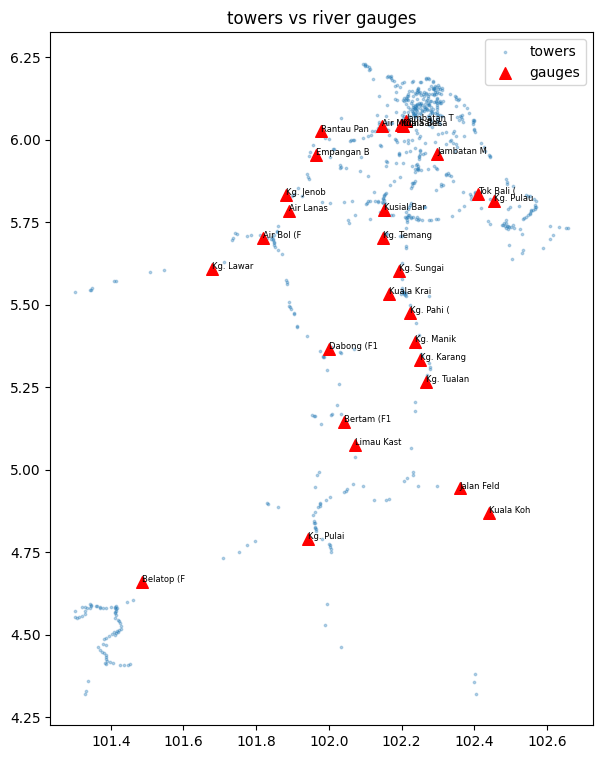

In [4]:
import matplotlib.pyplot as plt
tw = pd.read_parquet(f"{BASE}/data/baseline.parquet")
plt.figure(figsize=(7,9))
plt.scatter(tw.lon, tw.lat, s=3, alpha=.3, label="towers")
plt.scatter(sc.lon, sc.lat, s=70, c="red", marker="^", label="gauges")
for r in sc.itertuples():
    plt.annotate(r.station.split(" di ")[-1][:10], (r.lon, r.lat), fontsize=6)
plt.legend(); plt.title("towers vs river gauges"); plt.show()

In [2]:
!rm -rf telcoshield && git clone -q https://github.com/jiayeekwong/telcoshield.git
import pandas as pd
BASE = "/content/drive/MyDrive/telcoshield"
log = pd.read_csv("telcoshield/data/river_log.csv")
print(log.shape, log.scraped_at.nunique(), "snapshots")

(32, 16) 1 snapshots
                              station station_id    district          river  lat  lon
     Sg. Melor di Jambatan Melor (F2)  0720101WL      Bachok      Sg. Melor None None
  Sg. Aring di Jalan Felda Aring (F1)        NaN  Gua Musang      Sg. Lebir None None
        Sg. Galas di Kg. Lembaga (F1)  0730851WL  Gua Musang      Sg. Galas None None
          Sg. Galas di Kg. Pulai (F1)        NaN  Gua Musang      Sg. Galas None None
      Sg. Galas di Limau Kasturi (F1)  0730931WL  Gua Musang      Sg. Galas None None
          Sg. Lebir di Kuala Koh (F1)  0731531WL  Gua Musang      Sg. Lebir None None
         Sg. Nenggiri di Belatop (F1)  0730891WL  Gua Musang   Sg. Nenggiri None None
          Sg. Nenggiri di Bertam (F1)  0730831WL  Gua Musang   Sg. Nenggiri None None
          Sg. Lanas di Air Lanas (F1)        NaN        Jeli      Sg. Lanas None None
           Sg. Pergau di Air Bol (F1)  0731241WL        Jeli     Sg. Pergau None None
         Sg. Pergau di Kg. Lawar 

In [5]:
import numpy as np
from scipy.spatial import cKDTree

def km(lat, lon):
    return np.column_stack([lon*111.32*np.cos(np.radians(lat)), lat*110.57])

d, i = cKDTree(km(sc.lat.values, sc.lon.values)).query(km(tw.lat.values, tw.lon.values), k=1)

smap = pd.DataFrame({"tower_id": tw.tower_id,
                     "station": sc.station.values[i],
                     "gauge_km": d.round(2)})
# beyond 15 km a gauge says nothing about local conditions. NOT zero —
# zero reads as "safe" downstream when it means "unknown".
smap.loc[smap.gauge_km > 15, "station"] = pd.NA
smap["has_river_signal"] = smap.station.notna()
smap.to_parquet(f"{BASE}/data/tower_station_map.parquet", index=False)

n = smap.has_river_signal.sum()
print(f"{n}/{len(smap)} towers within 15 km of a gauge ({n/len(smap):.0%})")
print(f"median distance {smap.gauge_km.median():.1f} km")

591/716 towers within 15 km of a gauge (83%)
median distance 8.8 km


**step 6**

All four inputs will exist:

baseline.parquet          susceptibility per tower
rain_climatology.parquet  per-tower rainfall distribution
tower_station_map.parquet 83% gauge coverage
river_log.csv             accumulating hourly on Actions

Step 6 joins them into live_score = static × multiplier, applies the gate stack, and writes a ranked list plus an archive row per cycle. That's the moment this becomes a live system rather than a static map.